# Multi-class Logistic Regression

In [42]:
import os
import numpy as np
import pandas as pd

try:
    s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
    print('From URL:', s)
    df = pd.read_csv(s,
                     header=None,
                     encoding='utf-8')

except HTTPError:
    s = 'iris.data'
    print('From local Iris path:', s)
    df = pd.read_csv(s,
                     header=None,
                     encoding='utf-8')

n_unique_categories = df[4].nunique()
unique_categories = df[4].unique()
print(f"There are {n_unique_categories} categories: {unique_categories}")

df.tail()

From URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
There are 3 categories: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


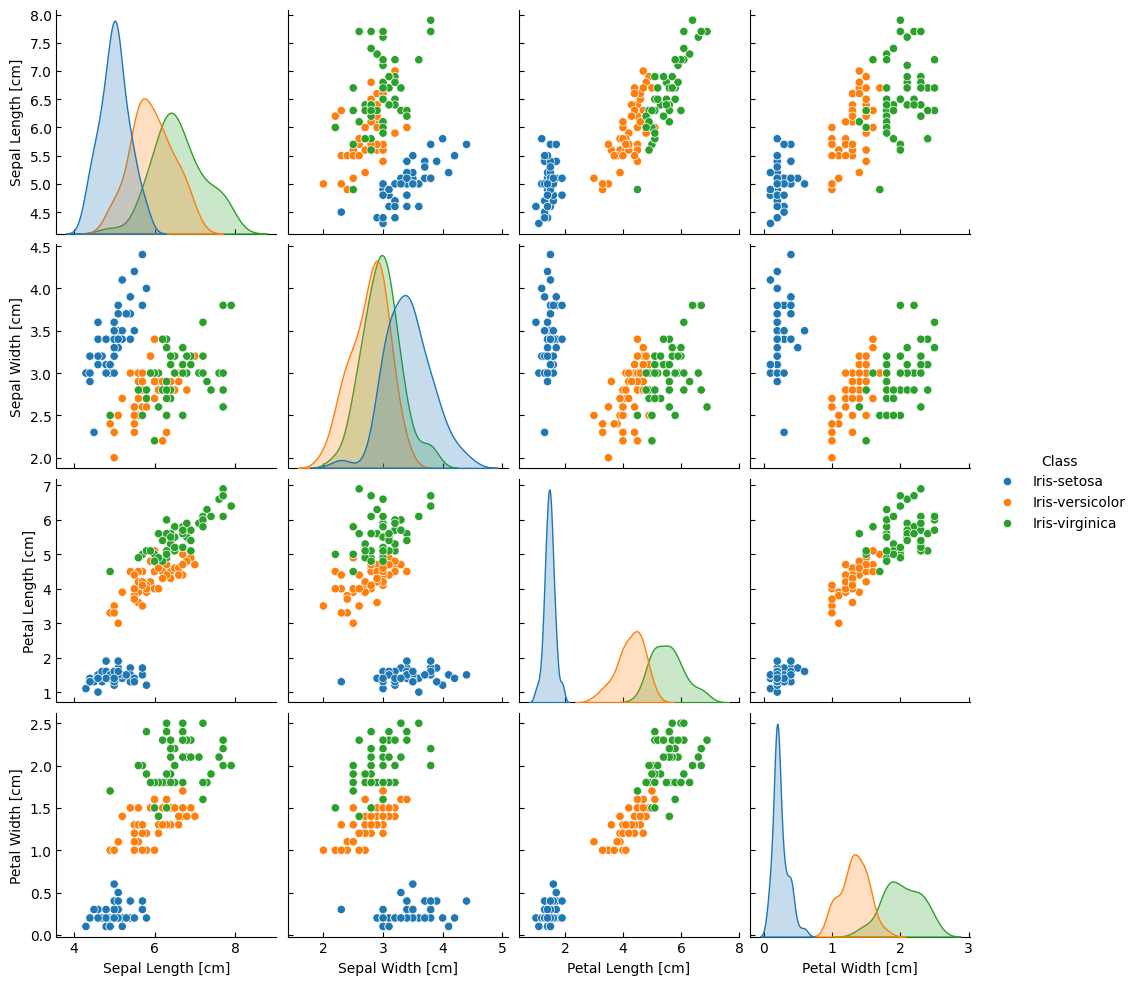

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
import seaborn as sns
sns.pairplot(df.rename(columns={
    0: 'Sepal Length [cm]',
    1: 'Sepal Width [cm]',
    2: 'Petal Length [cm]',
    3: 'Petal Width [cm]',
    4: 'Class',
}), hue='Class')

In [23]:
# We are going to classify all three Iris-subspecies
X = df[[0, 2]].values
y = df[4].values
labels = np.unique(y)

y_mapped = np.zeros([y.shape[0], len(labels)], dtype=int)
for i, label in enumerate(labels):
    y_mapped[y == label, i] = 1.

print(f"Fitting a dataset with X: {X.shape} and y: {y.shape}")

Fitting a dataset with X: (150, 2) and y: (150,)


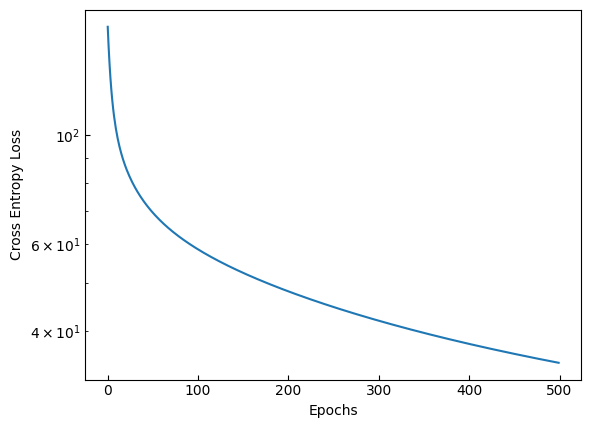

In [24]:
import numpy as np

def multiclass_cross_entropy(y, y_model, eps=1e-10):
    return -np.sum(y * np.log(y_model + eps))

class LogisticRegression:
    """ Gradient descent variant
        
        Parameters:
        -----------
        eta : float - Learning rate between 0 and 1
        n_epochs : int - Iterations over the training set
        random_seed : int - Random seed

        Attributes:
        -----------
        w_ : 1d array of weights
        b_ : bias term
        losses_ : MSE loss each epoch
    """
    def __init__(self, 
                 eta=0.25, 
                 n_epochs=100, 
                 random_seed=42):
        self.eta = eta
        self.n_epochs = n_epochs
        self.random_seed = random_seed

    def fit(self, X, y):
        """ X : ndarray with shape [n_examples, n_features]
            y : ndarray with shape [n_examples, n_classes]
        """
        N, k = X.shape
        _, c = y.shape

        self.X_mean_ = X.mean(axis=0)
        self.X_std_ = X.std(axis=0)
        X_std = self._standardize(X)

        self.rng = np.random.default_rng(seed=self.random_seed)
        self.w_ = self.rng.normal(loc=0, scale=0.01, size=[k, c])
        self.b_ = np.zeros(c)

        self.losses_ = []

        # iterate over epochs
        for _ in range(self.n_epochs):
             loss = self._fit_epoch(X_std, y)
             self.losses_.append(loss)

        return self

    def _fit_epoch(self, X, y):
        z = self.pre_activation(X) #[N, c]
        pred = self.activation(z) #[N, c]
        diff = y - pred #[N, c]

        self.w_ += 2. * self.eta * np.einsum('Bi,Bj->ij', X, diff) / X.shape[0]
        self.b_ += 2. * self.eta * diff.mean(axis=0) # [C,]

        loss = multiclass_cross_entropy(y, pred)

        return loss

    def _standardize(self, X):
        return (X - self.X_mean_) / self.X_std_

    def pre_activation(self, X):
        return np.dot(X, self.w_) + self.b_

    def activation(self, z):
        zr = z - np.max(z)
        expz = np.exp(z)
        return expz / np.sum(expz, axis=1, keepdims=True)

    def predict(self, X):
        X_std = self._standardize(X)
        z = self.pre_activation(X_std)
        y = self.activation(z)
        return np.argmax(y, axis=1)

lr_model = LogisticRegression(eta=0.1, n_epochs=500)
lr_model.fit(X, y_mapped)

ax = plt.figure().gca()
ax.plot(lr_model.losses_)
ax.set(xlabel='Epochs', ylabel='Cross Entropy Loss', yscale='log');

[Text(0.5, 0, 'Sepal length [cm]'), Text(0, 0.5, 'Petal length [cm]')]

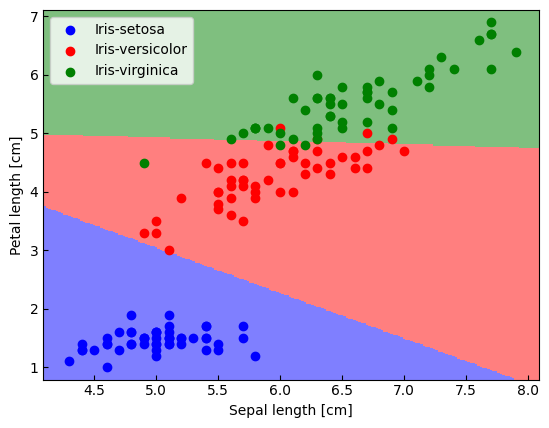

In [41]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.02, colors=['blue', 'red', 'green'], labels=None):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min()-10*d, X[:, 0].max()+10*d, d),
        np.arange(X[:, 1].min()-10*d, X[:, 1].max()+10*d, d),
    )
    y_model = model.predict(np.stack([x1.ravel(), x2.ravel()]).T)
    y_model = y_model.reshape(x1.shape)

    cmap = ListedColormap(colors)
    im=ax.pcolormesh(x1, x2, y_model, alpha=0.5, cmap=cmap)
    for label in range(y.shape[1]):
        mask = y[:, label] == 1
        ax.scatter(X[mask, 0], X[mask, 1], color=colors[label], label=labels[label] if labels is not None else None)
    if labels is not None:
        ax.legend()
    return ax

ax = plt.figure().gca()
plot_decision_boundary(ax, X, y_mapped, lr_model, labels=labels)
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')